In [3]:
import torch
import cv2
import ultralytics
import matplotlib

print(f"PyTorch: {torch.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cpu
OpenCV: 4.13.0
Ultralytics: 8.4.47
Matplotlib: 3.10.9
GPU disponível: False


In [4]:
from roboflow import Roboflow
import os

# Vai para a pasta data/raw do projeto
os.makedirs("data/raw", exist_ok=True)
os.chdir("data/raw")

# Baixa o dataset
rf = Roboflow(api_key="FJe0HeGAhRdivS17VsQL")
project = rf.workspace("roboflow-100").project("weed-crop-aerial")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset baixado com sucesso!")
print(f"Localização: {os.getcwd()}")

loading Roboflow workspace...
loading Roboflow project...
Dataset baixado com sucesso!
Localização: c:\projetos\soja-weed-detection\notebooks\data\raw


In [5]:
import os

# Caminho onde ficou o dataset
dataset_path = "weed-crop-aerial-1"

# Lista o que tem dentro
for pasta in os.listdir(dataset_path):
    caminho = os.path.join(dataset_path, pasta)
    if os.path.isdir(caminho):
        arquivos = os.listdir(caminho)
        print(f"\n📁 {pasta}/ — {len(arquivos)} itens")
        for sub in os.listdir(caminho):
            sub_caminho = os.path.join(caminho, sub)
            if os.path.isdir(sub_caminho):
                qtd = len(os.listdir(sub_caminho))
                print(f"   📁 {sub}/ — {qtd} arquivos")
    else:
        print(f"📄 {pasta}")

📄 data.yaml
📄 README.dataset.txt
📄 README.roboflow.txt

📁 test/ — 2 itens
   📁 images/ — 118 arquivos
   📁 labels/ — 118 arquivos

📁 train/ — 2 itens
   📁 images/ — 823 arquivos
   📁 labels/ — 823 arquivos

📁 valid/ — 2 itens
   📁 images/ — 235 arquivos
   📁 labels/ — 235 arquivos


In [6]:
# Lê um arquivo de label para ver como é a anotação
label_path = "weed-crop-aerial-1/train/labels"
arquivo = os.listdir(label_path)[0]  # pega o primeiro arquivo

with open(os.path.join(label_path, arquivo), "r") as f:
    conteudo = f.read()

print(f"Arquivo: {arquivo}")
print(f"\nConteúdo:\n{conteudo}")

Arquivo: 12114_jpg.rf.668621a4d1d4ae21201fdf4977ab1d20.txt

Conteúdo:
1 0.3 0.31328125 0.06875 0.140625


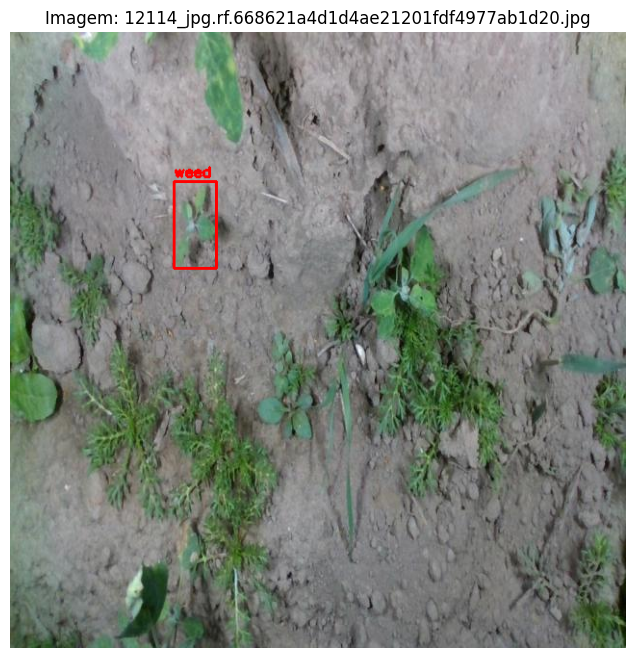

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Caminhos
img_path = "weed-crop-aerial-1/train/images"
label_path = "weed-crop-aerial-1/train/labels"

# Pega a primeira imagem e o label correspondente
label_arquivo = os.listdir(label_path)[0]
img_arquivo = label_arquivo.replace(".txt", ".jpg")

# Lê a imagem
img = cv2.imread(os.path.join(img_path, img_arquivo))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Lê as anotações e desenha as caixinhas
cores = {0: (0, 255, 0), 1: (255, 0, 0)}   # verde=crop, vermelho=weed
nomes = {0: "crop", 1: "weed"}

with open(os.path.join(label_path, label_arquivo)) as f:
    for linha in f:
        valores = linha.strip().split()
        classe = int(valores[0])
        cx, cy, bw, bh = map(float, valores[1:])

        # Converte de porcentagem para pixels
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)

        cv2.rectangle(img, (x1,y1), (x2,y2), cores[classe], 2)
        cv2.putText(img, nomes[classe], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cores[classe], 2)

# Exibe
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Imagem: {img_arquivo}")
plt.axis("off")
plt.show()

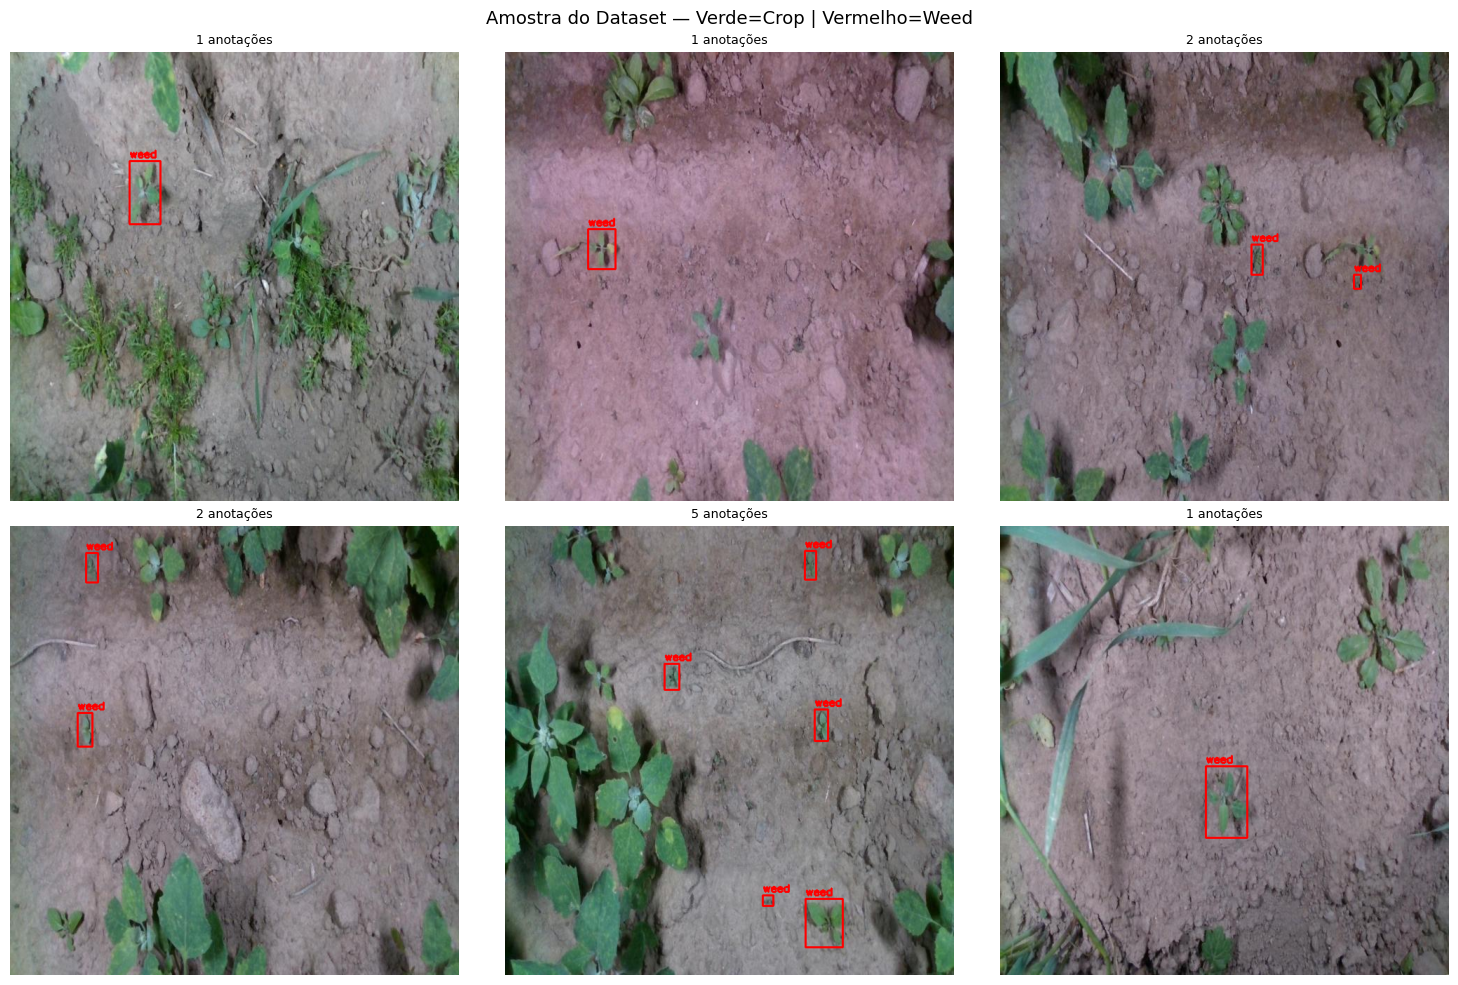

In [8]:
# Visualiza 6 imagens do dataset para ter uma visão geral
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

imagens = os.listdir(img_path)[:6]

for idx, img_arquivo in enumerate(imagens):
    label_arquivo = img_arquivo.replace(".jpg", ".txt")
    label_completo = os.path.join(label_path, label_arquivo)
    
    img = cv2.imread(os.path.join(img_path, img_arquivo))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    if os.path.exists(label_completo):
        with open(label_completo) as f:
            linhas = f.readlines()
            for linha in linhas:
                valores = linha.strip().split()
                classe = int(valores[0])
                cx, cy, bw, bh = map(float, valores[1:])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cor = (0, 255, 0) if classe == 0 else (255, 0, 0)
                nome = "crop" if classe == 0 else "weed"
                cv2.rectangle(img, (x1,y1), (x2,y2), cor, 2)
                cv2.putText(img, nome, (x1, y1-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"{len(linhas)} anotações", fontsize=9)
    axes[idx].axis("off")

plt.suptitle("Amostra do Dataset — Verde=Crop | Vermelho=Weed", fontsize=13)
plt.tight_layout()
plt.show()

=== Distribuição das classes — Treino ===
crop: 278 anotações (5.1%)
weed: 5188 anotações (94.9%)


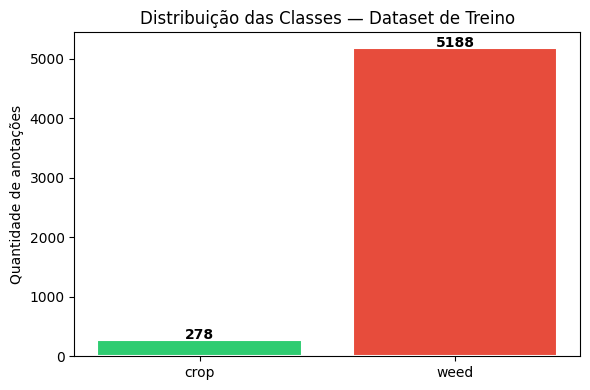

In [9]:
import matplotlib.pyplot as plt

# Conta as classes em todo o dataset de treino
contagem = {"crop": 0, "weed": 0}
nomes = {0: "crop", 1: "weed"}

for label_arquivo in os.listdir(label_path):
    with open(os.path.join(label_path, label_arquivo)) as f:
        for linha in f:
            classe = int(linha.strip().split()[0])
            contagem[nomes[classe]] += 1

# Exibe os números
print("=== Distribuição das classes — Treino ===")
total = sum(contagem.values())
for classe, qtd in contagem.items():
    percentual = (qtd / total) * 100
    print(f"{classe}: {qtd} anotações ({percentual:.1f}%)")

# Gráfico
plt.figure(figsize=(6, 4))
plt.bar(contagem.keys(), contagem.values(), 
        color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
plt.title("Distribuição das Classes — Dataset de Treino")
plt.ylabel("Quantidade de anotações")
for i, (classe, qtd) in enumerate(contagem.items()):
    plt.text(i, qtd + 5, str(qtd), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

=== Tamanho médio dos bounding boxes (% da imagem) ===
Largura média geral:  3.1%
Altura média geral:   4.9%

Por classe:
  crop: 5.9% largura x 7.5% altura
  weed: 3.0% largura x 4.7% altura


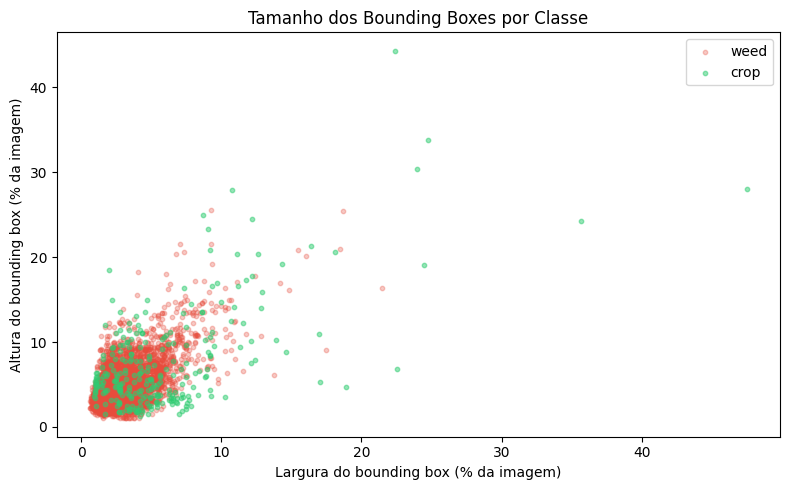

In [10]:
import numpy as np

# Coleta largura e altura de todos os bounding boxes do treino
larguras = []
alturas = []
nomes = {0: "crop", 1: "weed"}
larguras_por_classe = {"crop": [], "weed": []}
alturas_por_classe = {"crop": [], "weed": []}

for label_arquivo in os.listdir(label_path):
    with open(os.path.join(label_path, label_arquivo)) as f:
        for linha in f:
            valores = linha.strip().split()
            classe = int(valores[0])
            bw = float(valores[3])  # largura
            bh = float(valores[4])  # altura
            larguras.append(bw)
            alturas.append(bh)
            larguras_por_classe[nomes[classe]].append(bw)
            alturas_por_classe[nomes[classe]].append(bh)

# Estatísticas gerais
print("=== Tamanho médio dos bounding boxes (% da imagem) ===")
print(f"Largura média geral:  {np.mean(larguras)*100:.1f}%")
print(f"Altura média geral:   {np.mean(alturas)*100:.1f}%")
print(f"\nPor classe:")
for classe in ["crop", "weed"]:
    larg = np.mean(larguras_por_classe[classe]) * 100
    alt  = np.mean(alturas_por_classe[classe]) * 100
    print(f"  {classe}: {larg:.1f}% largura x {alt:.1f}% altura")

# Gráfico de dispersão
plt.figure(figsize=(8, 5))
plt.scatter(
    [l*100 for l in larguras_por_classe["weed"]],
    [a*100 for a in alturas_por_classe["weed"]],
    alpha=0.3, color="#e74c3c", label="weed", s=10)
plt.scatter(
    [l*100 for l in larguras_por_classe["crop"]],
    [a*100 for a in alturas_por_classe["crop"]],
    alpha=0.5, color="#2ecc71", label="crop", s=10)
plt.xlabel("Largura do bounding box (% da imagem)")
plt.ylabel("Altura do bounding box (% da imagem)")
plt.title("Tamanho dos Bounding Boxes por Classe")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Lê o arquivo de configuração do dataset
with open("weed-crop-aerial-1/data.yaml", "r") as f:
    print(f.read())

names:
- crop
- weed
nc: 2
roboflow:
  license: CC BY 4.0
  project: weed-crop-aerial
  url: https://universe.roboflow.com/roboflow-100/weed-crop-aerial/dataset/1
  version: 1
  workspace: roboflow-100
test: ../test/images
train: ../train/images
val: ../valid/images

